              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       100
        spam       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



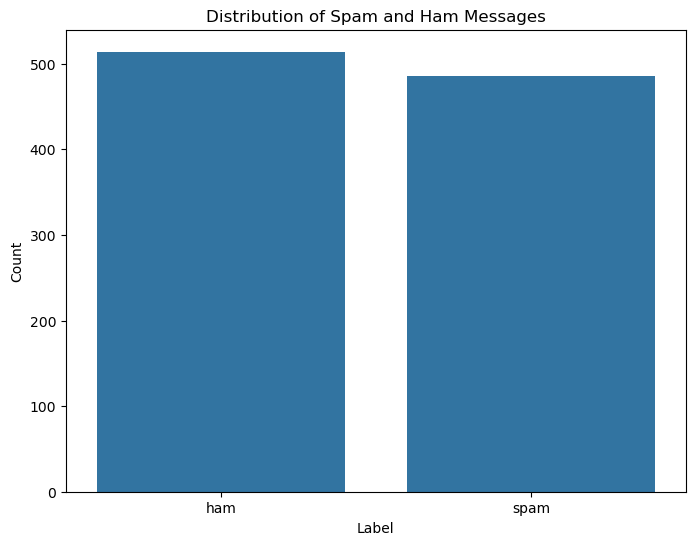

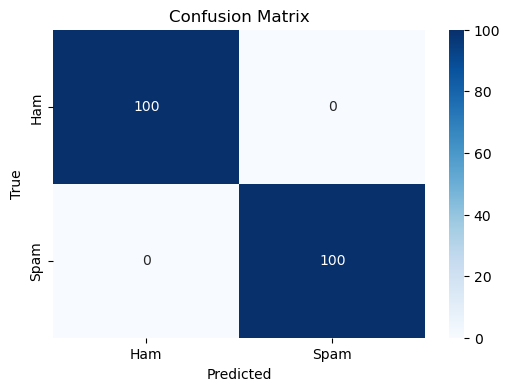

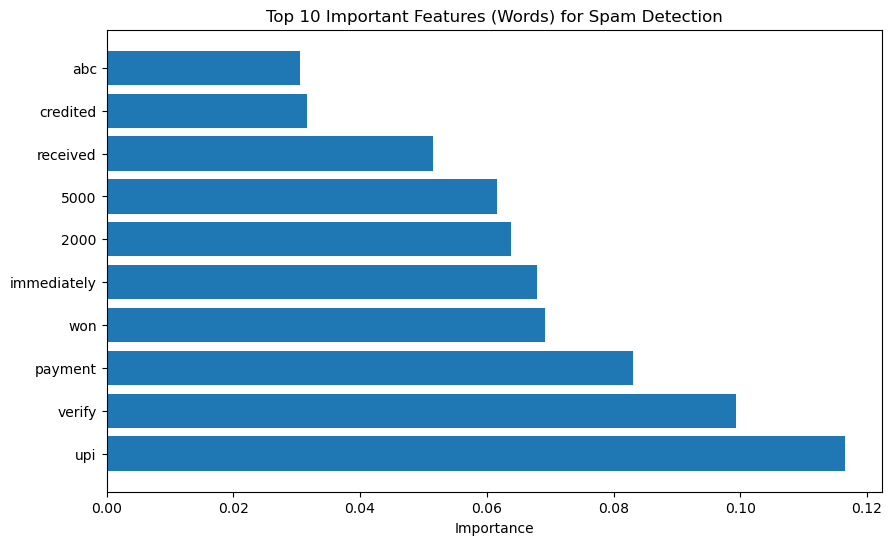

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import joblib

# Step 1: Creating a synthetic dataset with more than 500 samples
messages = []
labels = []

# Sample messages for spam and ham
ham_messages = [
    "Your UPI payment of ₹1000 is successful",
    "You received ₹5000 from ABC Ltd.",
    "Transaction of ₹2000 was credited to your account",
    "Thank you for your UPI payment of ₹1500",
    "Your UPI payment of ₹2000 has been received"
]

spam_messages = [
    "Your account has been suspended. Click here to verify your identity",
    "Congratulations! You've won ₹10000! Contact us immediately",
    "Your UPI transaction was unsuccessful. Please verify your details",
    "Urgent! Your account has been compromised. Change your password immediately",
    "You have won a ₹5000 gift card! Claim now!"
]

# Create 500+ messages
for i in range(1000):
    if random.random() > 0.5:  # 50% chance of spam/ham
        messages.append(random.choice(ham_messages))
        labels.append('ham')
    else:
        messages.append(random.choice(spam_messages))
        labels.append('spam')

# Create DataFrame
df = pd.DataFrame({'Message': messages, 'Label': labels})

# Save dataset to CSV
df.to_csv('upi_messages_large.csv', index=False)

# Step 2: Training the Random Forest Model
# Load dataset
df = pd.read_csv('upi_messages_large.csv')

# Split dataset into features (X) and labels (y)
X = df['Message']
y = df['Label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert text to numerical data using TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

# Evaluate the model
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

# Save the trained model and vectorizer
joblib.dump(model, 'upi_spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

# Step 3: Visualizing the Data and Model Results

# 1. Visualizing the distribution of labels (spam vs ham)
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df)
plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# 2. Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 3. Plotting feature importance from Random Forest model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Get top 10 important features
top_n = 10
top_features = [vectorizer.get_feature_names_out()[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(top_features, top_importances)
plt.xlabel('Importance')
plt.title('Top 10 Important Features (Words) for Spam Detection')
plt.show()

In [4]:
from flask import Flask, render_template, request
import joblib
import numpy as np

# Initialize Flask app
app = Flask(__name__)

# Load the trained model and vectorizer
model = joblib.load('upi_spam_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')


# Home route (for input form)
@app.route('/')
def home():
    return render_template('index.html')


# Prediction route (handles form submission and shows result)
@app.route('/predict', methods=['POST'])
def predict():
    if request.method == 'POST':
        # Get the message input from the form
        user_message = request.form['message']

        # Vectorize the input message
        input_tfidf = vectorizer.transform([user_message])

        # Make prediction using the loaded model
        prediction = model.predict(input_tfidf)[0]

        # Render the result page with the message and prediction
        return render_template('result.html', message=user_message, prediction=prediction)


# Run the app
if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1